In [2]:
from dateutil.parser import parse 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot

from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

globtemp2
from scipy.stats import norm
import statsmodels.api as sm
from datetime import datetime

from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) 

In [21]:
# dataset source: https://github.com/rouseguy
df = pd.read_csv('C://Users/crisr/Documents/ASN_Rocks/Series_Temporais/4. Curso_Completo - Aulas_3_horas/Dados/globtemp_1.csv')
df.head(10)

,Ano,serie
0,1880,-0.11
1,1881,-0.13
2,1882,-0.01
3,1883,-0.04
4,1884,-0.42
5,1885,-0.23
6,1886,-0.25
7,1887,-0.45
8,1888,-0.23
9,1889,0.04


In [22]:
df = df['serie']
df.head(10)

0   -0.11
1   -0.13
2   -0.01
3   -0.04
4   -0.42
5   -0.23
6   -0.25
7   -0.45
8   -0.23
9    0.04
Name: serie, dtype: float64

In [3]:
################################
################################
#1. Visualizando a série temporal

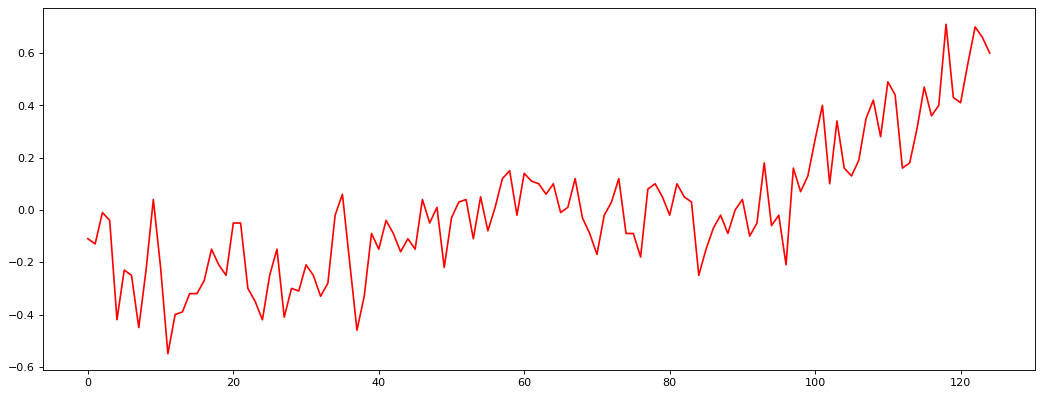

In [23]:
fig  = plt.subplots(1, figsize=(16,6), dpi= 80)
plt.plot(df, color='red')

In [5]:
################################
################################
#2. Verificando se a série é um Ruído Branco
#Usando Teste Ljung-Box

In [24]:
sm.stats.acorr_ljungbox(df, lags=[5], return_df=True)

,lb_stat,lb_pvalue
5,315.401179,4.883624e-66


p_valor < nível_significancia  => rejeitar a hipotese nula => série não é ruído branco

In [25]:
################################
################################
#3. Verificando se a série é Estacionária
# ADF test 
#ADF test, where the null hypothesis is the time series possesses a unit root and is non-stationary. 
#So, id the P-Value in ADH test is less than the significance level (0.05), you reject the null hypothesis.
result = adfuller(df, autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: 1.2686695322436516
p-value: 0.9964276216261223


p_valor > nível_significancia  => não rejeita a hipotese nula => série não é estacionaria

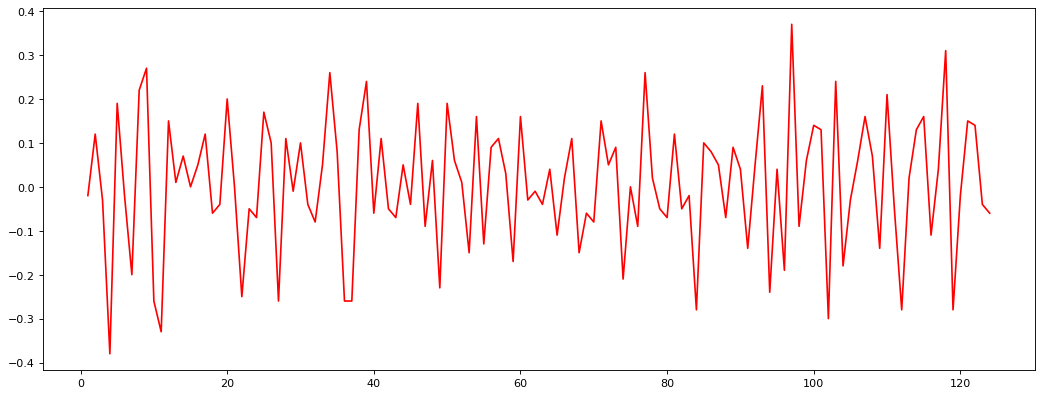

In [26]:
################################
################################
#4. Aplicando uma diferenciação para tornar a serie estacionáriaa
df_diff = df.diff()
fig  = plt.subplots(1, figsize=(16,6), dpi= 80)
plt.plot(df_diff, color='red')

In [27]:
df_diff.head(5)

0     NaN
1   -0.02
2    0.12
3   -0.03
4   -0.38
Name: serie, dtype: float64

In [12]:
#df.head(5)

In [28]:
# verificar se a serie diferenciada é estacionária
teste = adfuller(df_diff.dropna(), autolag='AIC')
print(f'ADF Statistic: {teste[0]}')
print(f'p-value: {teste[1]}')

ADF Statistic: -8.126861351681057
p-value: 1.1171252450668093e-12


p_valor < nível_significancia =>  rejeita a hipotese nula => série  é estacionaria

In [ ]:
################################
################################
#5. IDENTIFICAÇÃO
# Verificando autocorrelação e autocorrelação parcial

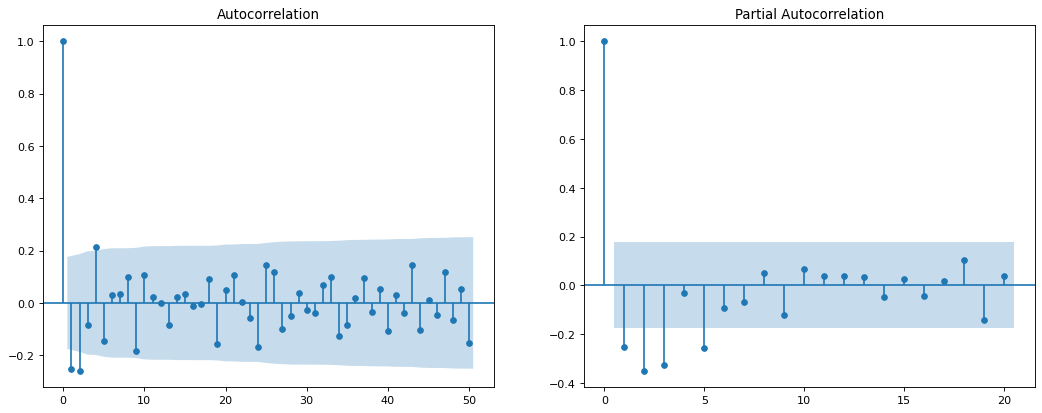

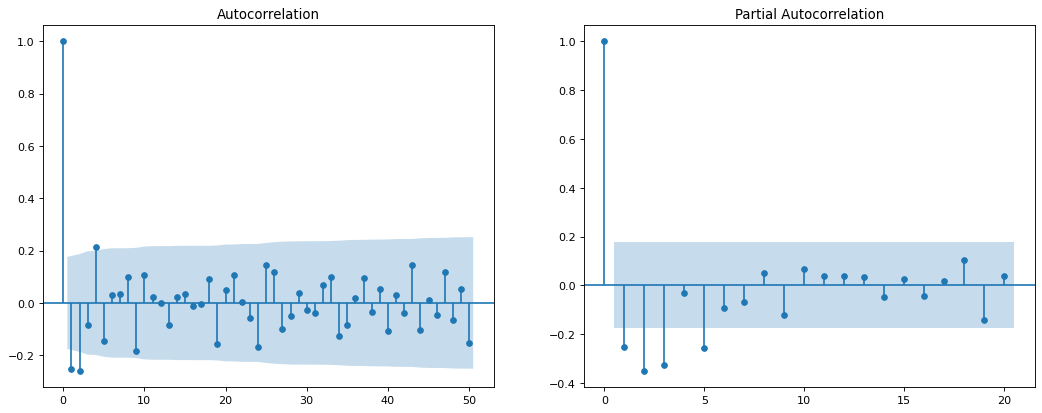

In [29]:
df_diff_1 = df_diff.dropna()
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16,6), dpi= 80)
plot_acf(df_diff_1, ax=ax1, lags=50)
plot_pacf(df_diff_1, ax=ax2, lags=20)

Vou testar num primeiro momento um ARIMA(3,1,2)

In [16]:
################################
################################
# 5. ESTIMAÇÃO
# Ajusta o modelo

In [31]:
model = sm.tsa.statespace.SARIMAX(df, order=(3,1,2))
results_ARIMA = model.fit()  
# summary of fit model
print(results_ARIMA.summary())

C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                  serie   No. Observations:                  125
Model:               SARIMAX(3, 1, 2)   Log Likelihood                  80.265
Date:                Mon, 13 Nov 2023   AIC                           -148.530
Time:                        19:57:53   BIC                           -131.608
Sample:                             0   HQIC                          -141.656
                                - 125                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6880      0.181     -3.807      0.000      -1.042      -0.334
ar.L2         -0.1455      0.199     -0.730      0.466      -0.537       0.245
ar.L3         -0.3255      0.096     -3.388      0.0

In [32]:
y_true = df.values
y_pred = results_ARIMA.fittedvalues
r2   = r2_score(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print('R2:   %.3f' % r2)
print('MSE:  %.3f' % mse)
print('RMSE: %.3f' % rmse)
print('MAE:  %.3f' % mae)
print('MAPE: %.3f' % mape)

R2:   0.756
MSE:  0.016
RMSE: 0.126
MAE:  0.099
MAPE: inf


C:\Users\crisr\AppData\Local\Temp/ipykernel_45212/1583112975.py:33: RuntimeWarning: divide by zero encountered in true_divide
  return np.mean(np.abs((y_true - y_pred) / y_true))


Todos os parametros são significantes e o AIC ficou menor

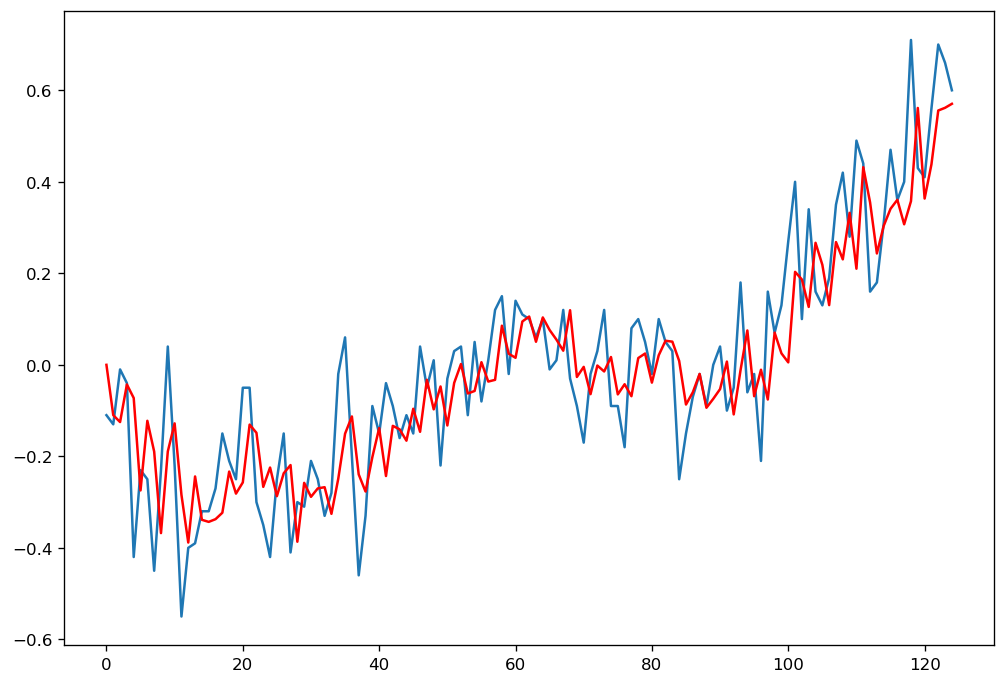

In [33]:
plt.plot(df)
plt.plot(results_ARIMA.fittedvalues,  color='red')

In [ ]:
################################
################################
# 6. VERIFICAÇÃO
# Avalia a qualidade do ajuste 

In [34]:
# Aplicando teste do ruido branco do resíduo
sm.stats.acorr_ljungbox(results_ARIMA.resid, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,5.076813,0.885988


In [35]:
################################
################################
# 6. PREVISÃO
predictions = results_ARIMA.forecast(30)

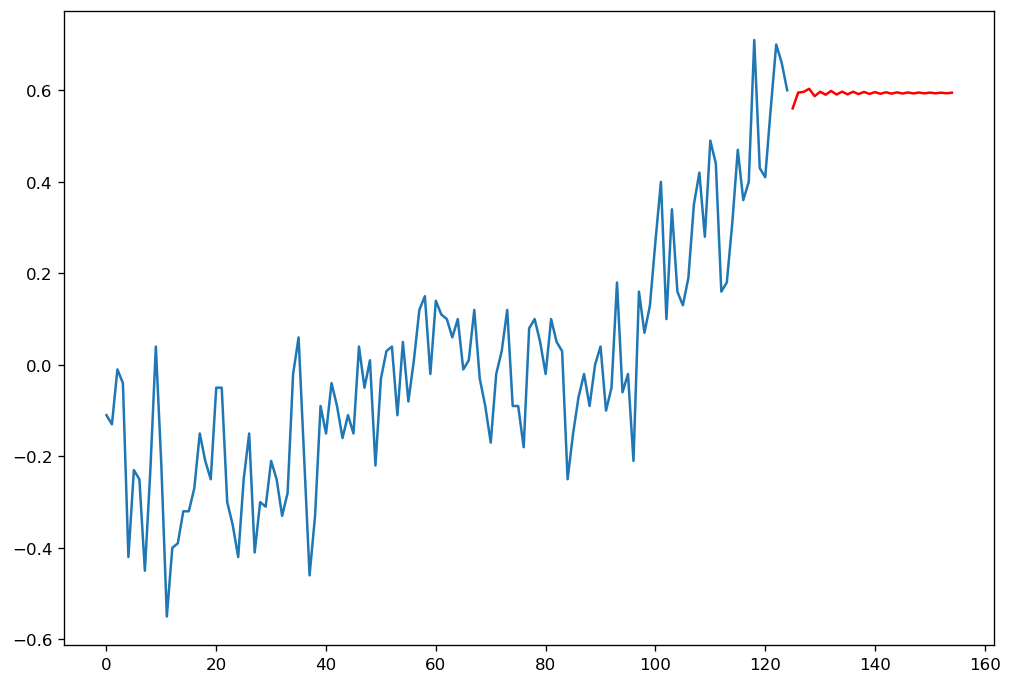

In [36]:
# plot forecasts against actual outcomes
pyplot.plot(df)
pyplot.plot(predictions, color='red')
pyplot.show()